使用变形模型的方法操作软体组织上的特征点到达目标位置

num=1时,delta=ti.Vector([0.004, 0.004])

num=2时,delta=ti.Vector([0.008, 0.])

num=3时,delta=ti.Vector([0.005, -0.003])

num=4时,delta=ti.Vector([0., -0.003])

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec

# 设置全局字体为 Times New Roman
rcParams['font.family'] = 'serif'
rcParams['font.serif'] = 'Times New Roman'

In [3]:
num = 3
df = pd.read_csv(f'experiment_data{num}.csv')

# 获取并输出列标题
column_titles = df.columns.tolist()
print('Column titles:')
print(column_titles)

loss_np = np.loadtxt(f'loss_list{num}.csv', delimiter=',')
dot_pixel_np = np.loadtxt(f'dot_pixel_list{num}.csv', delimiter=',')
rob_mov_np = np.loadtxt(f'rob_movement_list{num}.csv', delimiter=',')

Column titles:
['timestamp', 'actual_TCP_pose_0', 'actual_TCP_pose_1', 'actual_TCP_pose_2', 'actual_TCP_pose_3', 'actual_TCP_pose_4', 'actual_TCP_pose_5', 'actual_TCP_speed_0', 'actual_TCP_speed_1', 'actual_TCP_speed_2', 'actual_TCP_speed_3', 'actual_TCP_speed_4', 'actual_TCP_speed_5']


In [4]:
time = df['timestamp'].to_numpy()
time -= time[0]

rob_pose_x = df['actual_TCP_pose_0'].to_numpy()
rob_pose_y = df['actual_TCP_pose_1'].to_numpy()

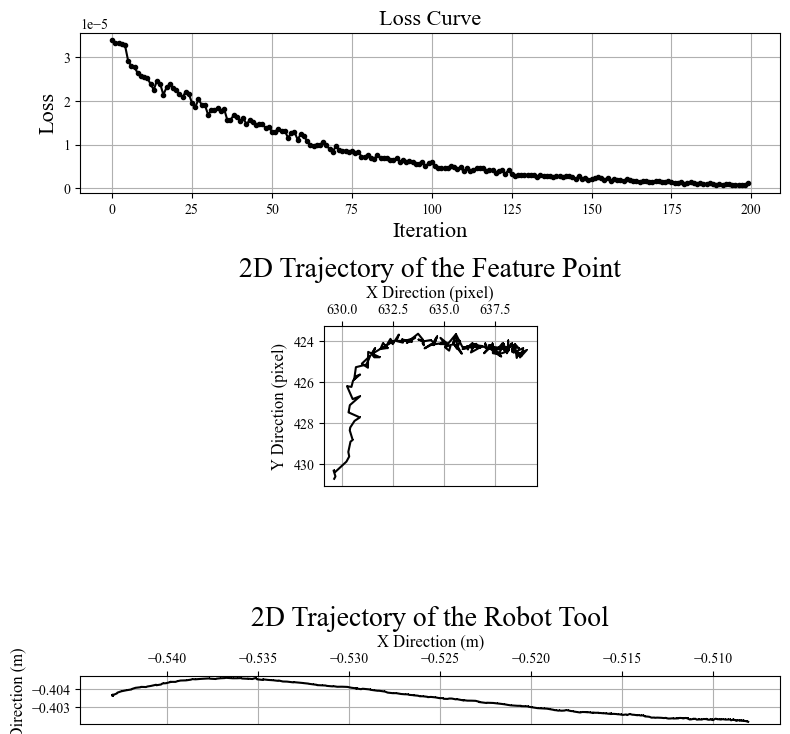

In [6]:
fig, axs= plt.subplots(3, 1, figsize=(8, 8))

axs[0].plot(loss_np, marker='.', linestyle='-', color='k', label='Loss')
axs[0].set_title('Loss Curve', fontsize=16, fontname='Times New Roman')
axs[0].set_xlabel('Iteration', fontsize=16, fontname='Times New Roman')
axs[0].set_ylabel('Loss', fontsize=16, fontname='Times New Roman')
axs[0].grid(True)

axs[1].plot(dot_pixel_np[:,0], dot_pixel_np[:,1], marker=',', linestyle='-', color='k', label='Trajectory')
axs[1].set_title('2D Trajectory of the Feature Point', fontsize=20, fontname='Times New Roman')
axs[1].set_xlabel('X Direction (pixel)', fontsize=12, fontname='Times New Roman')
axs[1].set_ylabel('Y Direction (pixel)', fontsize=12, fontname='Times New Roman')
# axs[0].set_xlim(634, 640)  # 根据你的数据范围调整
# axs[0].set_ylim(208.2, 207)  # 这里反转 y 轴
axs[1].invert_yaxis()
axs[1].xaxis.set_label_position('top')
axs[1].xaxis.tick_top()
axs[1].set_aspect('equal', 'box')
axs[1].grid(True)

sample_rate = 50
axs[2].plot(-rob_pose_x[::sample_rate], rob_pose_y[::sample_rate], marker=',', linestyle='-', color='k', label='Trajectory')
axs[2].set_title('2D Trajectory of the Robot Tool', fontsize=20, fontname='Times New Roman')
axs[2].set_xlabel('X Direction (m)', fontsize=12, fontname='Times New Roman')
axs[2].set_ylabel('Y Direction (m)', fontsize=12, fontname='Times New Roman')
axs[2].invert_yaxis()
axs[2].xaxis.set_label_position('top')
axs[2].xaxis.tick_top()
axs[2].set_aspect('equal', 'box')
axs[2].grid(True)

plt.tight_layout()
# plt.subplots_adjust(hspace=1.)  # 调整子图之间的间距
plt.show()